# ✈️ Airline Social Media Sentiment Analysis – Advanced Case Study

## 📌 Objective
This project analyzes customer sentiment from airline-related tweets to uncover key drivers of satisfaction, dissatisfaction, and engagement.

## 🧠 Business Problem
Airlines face increasing pressure to manage brand perception on social media. Understanding customer sentiment can help:
- Improve service quality
- Reduce negative publicity
- Enhance customer engagement

## 🛠 Tools & Technologies
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- NLP Techniques
- Tableau (for dashboarding)

---

## 🔎 Analytical Approach
1. Data Cleaning & Preprocessing  
2. Exploratory Data Analysis (EDA)  
3. Sentiment Distribution Analysis  
4. Complaint Category Analysis  
5. Time-based Trend Analysis  
6. Business Insight Generation  

---


### Importing Required Libraries for Data Analysis & Visualization

In this step, we import the essential Python libraries needed for data manipulation, numerical computation, and visualization:

- **pandas**: Used for data loading, cleaning, and manipulation through DataFrames.
- **numpy**: Provides support for numerical operations and working with arrays.
- **matplotlib.pyplot**: A core plotting library used to create static visualizations.
- **seaborn**: Built on top of matplotlib, used for creating more advanced and visually appealing statistical plots.

Additionally, `%matplotlib inline` ensures that all plots are displayed directly within the Jupyter Notebook environment, making analysis more interactive and convenient.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display charts inside notebook
%matplotlib inline

### Initialization Successful

The libraries have been successfully imported and configured. This step sets up the environment for the entire analysis workflow, enabling efficient data handling and high-quality visualizations in subsequent steps.

No output is expected from this cell, as it only prepares the necessary tools for further analysis.

### Loading the Dataset

In this step, we load the dataset into the Python environment using the `pandas` library.

- The `read_csv()` function is used to read data from a CSV (Comma-Separated Values) file.
- The file path provided points to the location where the dataset (`Tweets.csv`) is stored on the local system.
- The dataset is stored in a DataFrame named `df`, which allows for structured data manipulation and analysis.

This step is crucial as it initializes the dataset that will be used throughout the analysis process.

In [2]:
df = pd.read_csv(r"C:\Users\Anirban Tarafdar\Documents\Tweets.csv")

### Dataset Loaded Successfully

The dataset has been successfully loaded into the DataFrame `df`.

At this stage, the data is now ready for exploration, cleaning, and analysis. In the following steps, we will inspect its structure, check for missing values, and understand the key features present in the dataset.

### Previewing the Dataset

After loading the dataset, it is important to inspect its structure and contents. 

- The `head()` function is used to display the first 5 rows of the DataFrame.
- This helps in understanding the dataset’s columns, data types, and sample values.
- It provides a quick overview of how the data is organized and whether it has been loaded correctly.

This step is essential for getting an initial sense of the dataset before performing any data cleaning or analysis.

In [3]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### Initial Observations from the Dataset

From the preview of the first 5 rows, we can draw the following insights:

- The dataset contains tweet-level information related to airlines, including features such as `tweet_id`, `airline_sentiment`, `airline`, and `text`.
- The target variable appears to be **`airline_sentiment`**, which classifies tweets as **positive, negative, or neutral**.
- Several columns contain missing values (`NaN`), such as `negativereason`, `tweet_coord`, and `tweet_location`, indicating the need for data cleaning.
- The `text` column holds the actual tweet content, which will be crucial for sentiment analysis.
- Timestamp (`tweet_created`) and user-related information (`user_timezone`) are also available, which may be useful for time-based or geographical analysis.

This step confirms that the dataset has been loaded correctly and gives a clear direction for the next steps, such as data cleaning and exploratory data analysis (EDA).

### Understanding Dataset Dimensions

In this step, we examine the overall size of the dataset using the `shape` attribute.

- `df.shape` returns a tuple representing the number of rows and columns in the DataFrame.
- This helps us understand how large the dataset is and how many features (variables) are available for analysis.

Knowing the dataset size is important for planning data preprocessing and computational requirements.

In [4]:
df.shape

(14640, 15)

### Dataset Size Insights

The dataset contains:

- **14,640 rows** → Each row represents an individual tweet.
- **15 columns** → These are the features describing each tweet (e.g., sentiment, airline, text, etc.).

This indicates that we are working with a moderately large dataset, sufficient for performing meaningful exploratory data analysis and building sentiment classification models.

The next step will involve exploring the data types and checking for missing values to prepare the dataset for further analysis.

### Exploring Column Names

In this step, we retrieve the names of all columns present in the dataset using `df.columns`.

- This provides a complete list of features available for analysis.
- Understanding column names is important for identifying relevant variables, especially the target variable and key predictors.
- It also helps in planning data cleaning, feature selection, and transformation steps.

This step ensures clarity about the dataset structure before moving deeper into analysis.

In [5]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

### Feature Overview

The dataset consists of 15 columns capturing different aspects of tweets and user information. Key observations include:

- **Target Variable**:
  - `airline_sentiment` → Indicates whether the sentiment is positive, negative, or neutral.

- **Confidence Scores**:
  - `airline_sentiment_confidence` and `negativereason_confidence` show how confident the labeling is.

- **Categorical Features**:
  - `airline` → Airline name associated with the tweet.
  - `negativereason` → Reason for negative sentiment (if applicable).

- **Text Data**:
  - `text` → Contains the actual tweet content, which is central to sentiment analysis.

- **User & Metadata**:
  - Includes `name`, `tweet_location`, `user_timezone`, and `tweet_created`.

- **Additional/Derived Fields**:
  - Columns like `airline_sentiment_gold` and `negativereason_gold` may represent manually verified labels.

This overview helps in identifying which columns are useful for analysis and which may require cleaning or removal in later stages.

### Inspecting Data Types and Missing Values

In this step, we use the `info()` function to get a concise summary of the dataset.

- It provides information about:
  - Total number of entries (rows)
  - Column names and their data types
  - Number of non-null (non-missing) values in each column
  - Memory usage of the dataset

This step is crucial for identifying missing values, understanding data types, and planning data preprocessing steps such as type conversion and handling null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

### Key Insights from Dataset Structure

From the dataset summary, several important observations can be made:

#### 📊 Data Types
- **Numerical Columns**:
  - `tweet_id`, `retweet_count` → Integer type
  - `airline_sentiment_confidence`, `negativereason_confidence` → Float type
- **Categorical/Text Columns**:
  - Majority of columns (11 out of 15) are of type `object`, including `text`, `airline`, and `airline_sentiment`.

#### ⚠️ Missing Values
- Significant missing values are present in several columns:
  - `negativereason` → Missing in many rows (only 9178 non-null)
  - `tweet_coord` → Highly sparse (only 1019 non-null)
  - `tweet_location` and `user_timezone` → Partially missing
  - `airline_sentiment_gold` and `negativereason_gold` → Almost entirely missing (very low non-null counts)

#### 🧠 Observations
- Columns with extremely low non-null values (like `*_gold` and `tweet_coord`) may not be useful and could be dropped.
- The `tweet_created` column is currently in `object` format and may need conversion to datetime for time-based analysis.
- The `text` column is complete and will be the primary feature for sentiment analysis.

#### 💾 Memory Usage
- The dataset uses approximately **1.7 MB**, which is efficient and manageable for analysis.

This step highlights the need for data cleaning, especially handling missing values and converting data types where necessary before proceeding to deeper analysis.

### Checking for Missing Values

In this step, we analyze the presence of missing (null) values in the dataset using `df.isnull().sum()`.

- This function returns the total count of null values for each column.
- Identifying missing data is a critical step in data preprocessing.
- It helps in deciding how to handle incomplete data, such as:
  - Dropping columns or rows
  - Imputing missing values
  - Ignoring irrelevant features

This step provides a clear picture of data quality before proceeding further.

In [7]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

### Missing Value Analysis

The output reveals the extent of missing data across different columns:

#### 🚨 Highly Missing Columns
- `airline_sentiment_gold` → 14,600 missing values
- `negativereason_gold` → 14,608 missing values
- `tweet_coord` → 13,621 missing values

➡️ These columns contain very little usable data and are strong candidates for removal.

#### ⚠️ Moderately Missing Columns
- `negativereason` → 5,462 missing values
- `negativereason_confidence` → 4,118 missing values
- `tweet_location` → 4,733 missing values
- `user_timezone` → 4,820 missing values

➡️ These may require imputation, selective usage, or conditional handling depending on their importance.

#### ✅ No Missing Values
- Key columns like `airline_sentiment`, `text`, `airline`, and `tweet_created` have **no missing values**, making them reliable for analysis.

#### 🧠 Key Takeaway
- The dataset contains a mix of complete and incomplete features.
- Columns with excessive missing values will likely be dropped to improve model performance and reduce noise.
- Critical columns for sentiment analysis (`text` and `airline_sentiment`) are clean and ready for use.

This step helps define the data cleaning strategy moving forward.

### Selecting Relevant Features

In this step, we perform feature selection by retaining only the most relevant columns from the dataset.

- Instead of working with all 15 columns, we narrow down the dataset to key features that are important for sentiment analysis.
- The selected columns include:
  - `airline` → Airline associated with the tweet
  - `airline_sentiment` → Target variable (sentiment label)
  - `negativereason` → Reason for negative sentiment (if applicable)
  - `retweet_count` → Engagement metric
  - `text` → Actual tweet content (primary input for analysis)
  - `tweet_created` → Timestamp of the tweet

This step helps reduce noise, improve computational efficiency, and focus the analysis on meaningful variables.

In [8]:
df = df[['airline',
         'airline_sentiment',
         'negativereason',
         'retweet_count',
         'text',
         'tweet_created']]

### Feature Reduction Completed

The dataset has now been reduced to **6 essential columns**, eliminating irrelevant or highly sparse features.

#### 🎯 Benefits of This Step:
- **Improved Data Quality**: Removed columns with excessive missing values and low relevance.
- **Better Performance**: Fewer features lead to faster processing and model training.
- **Focused Analysis**: Retains only the variables that directly contribute to sentiment analysis and insights.

#### 🧠 Key Insight:
- The `text` and `airline_sentiment` columns will form the core of the sentiment analysis task.
- Additional features like `airline` and `retweet_count` can help in deriving deeper business insights such as airline-wise sentiment trends and engagement patterns.

The dataset is now cleaner and more suitable for further preprocessing and exploratory data analysis (EDA).

### Verifying the Updated Dataset

After selecting the relevant features, we again use the `head()` function to preview the dataset.

- This helps confirm that only the desired columns have been retained.
- It ensures that the feature selection step was executed correctly.
- It also allows us to quickly inspect the structure and sample values of the refined dataset.

This step acts as a validation checkpoint before proceeding further.

In [9]:
df.head()

,airline,airline_sentiment,negativereason,retweet_count,text,tweet_created
0,Virgin America,neutral,NaN,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800
1,Virgin America,positive,NaN,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800
2,Virgin America,neutral,NaN,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800
3,Virgin America,negative,Bad Flight,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800
4,Virgin America,negative,Can't Tell,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800


### Cleaned Dataset Preview

From the updated preview, we can confirm the following:

#### ✅ Successful Feature Selection
- The dataset now contains only the 6 selected columns:
  - `airline`, `airline_sentiment`, `negativereason`, `retweet_count`, `text`, and `tweet_created`.

#### 📊 Observations
- The `airline_sentiment` column clearly shows the three sentiment categories: **positive, negative, and neutral**.
- The `negativereason` column contains values only for negative tweets, while others remain `NaN`, which is expected behavior.
- The `text` column contains raw tweet data, which will be used for text preprocessing and sentiment modeling.
- The `tweet_created` column still appears as a string and may need conversion to datetime format for time-based analysis.

#### 🧠 Key Takeaway
- The dataset is now cleaner, more focused, and ready for the next steps such as text preprocessing, handling missing values, and exploratory data analysis.

This confirms that the data preparation process is on the right track.

### Converting Timestamp to Datetime Format

In this step, we convert the `tweet_created` column from a string (`object`) data type to a proper datetime format using `pd.to_datetime()`.

- This transformation allows us to treat the column as a time-based feature.
- It enables efficient time-series analysis, such as:
  - Extracting date, time, day, or month
  - Analyzing trends over time
  - Sorting and filtering based on timestamps

This step is essential for unlocking temporal insights from the dataset.

In [10]:
df['tweet_created'] = pd.to_datetime(df['tweet_created'])

### Datetime Conversion Successful

The `tweet_created` column has been successfully converted into a datetime format.

#### 🎯 Benefits of This Conversion:
- Enables advanced time-based operations such as grouping, filtering, and trend analysis.
- Improves data consistency and ensures accurate interpretation of timestamps.
- Allows extraction of useful features like:
  - Year, month, day
  - Hour of tweet activity
  - Day of the week

#### 🧠 Key Insight:
- With this conversion, we can now analyze patterns such as peak tweeting hours, daily sentiment trends, or time-based engagement behavior.

The dataset is now better structured for both exploratory analysis and feature engineering.

### Feature Engineering: Extracting Date and Hour

In this step, we perform feature engineering by extracting useful components from the `tweet_created` datetime column.

- `df['date'] = df['tweet_created'].dt.date`
  - Extracts only the **date** (year-month-day) from the timestamp.
- `df['hour'] = df['tweet_created'].dt.hour`
  - Extracts the **hour of the day** (0–23) when the tweet was posted.

These new features help in analyzing temporal patterns in the data, such as daily trends and hourly tweet activity.

In [11]:
df['date'] = df['tweet_created'].dt.date
df['hour'] = df['tweet_created'].dt.hour

### New Time-Based Features Created

Two new columns have been successfully added to the dataset:

#### 📅 `date`
- Represents the calendar date of each tweet.
- Useful for analyzing trends over days or identifying peak activity dates.

#### ⏰ `hour`
- Represents the hour of the day when the tweet was posted.
- Enables analysis of user activity patterns and peak engagement hours.

#### 🧠 Key Insights:
- These features allow us to perform **time-based exploratory analysis**, such as:
  - Identifying when users are most active
  - Analyzing sentiment variation across different times of the day
  - Detecting patterns like peak complaint hours

This step enhances the dataset by adding meaningful temporal dimensions for deeper analysis.

### Analyzing Sentiment Distribution

In this step, we examine the distribution of the target variable `airline_sentiment` using the `value_counts()` function.

- This function counts the number of occurrences of each unique category in the column.
- It helps us understand how the sentiment labels (positive, negative, neutral) are distributed across the dataset.

This is an important step to check for class imbalance, which can significantly impact model performance in classification tasks.

In [12]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

### Sentiment Distribution Insights

The dataset shows the following distribution of sentiments:

- **Negative** → 9,178 tweets (~62.7%)
- **Neutral** → 3,099 tweets (~21.2%)
- **Positive** → 2,363 tweets (~16.1%)

#### ⚠️ Key Observation: Class Imbalance
- The dataset is **heavily skewed towards negative sentiment**.
- Positive tweets are significantly fewer compared to negative ones.

#### 🧠 Business Insights:
- A large proportion of tweets express **negative experiences**, indicating potential customer dissatisfaction with airlines.
- This highlights areas where airlines may need to improve service quality.
  
#### 🤖 Modeling Implication:
- The imbalance may bias machine learning models toward predicting the majority class (negative).
- Techniques like **resampling, class weighting, or evaluation metrics (F1-score, precision-recall)** should be considered to handle this imbalance.

This step provides a crucial understanding of the target variable before building any predictive models.

### Saving the Cleaned Dataset

In this step, we export the cleaned and processed dataset to a new CSV file using the `to_csv()` function.

- The file is saved as **`cleaned_airline_sentiment.csv`**.
- `index=False` ensures that the DataFrame index is not included in the saved file.
- This allows us to preserve only the actual data columns in the output file.

Saving the dataset is important for:
- Reusability in future analysis or modeling
- Sharing the cleaned data with others
- Avoiding repetition of preprocessing steps

In [13]:
df.to_csv("cleaned_airline_sentiment.csv", index=False)

### Dataset Export Completed

The cleaned dataset has been successfully saved as **`cleaned_airline_sentiment.csv`**.

#### 🎯 Benefits of This Step:
- Provides a ready-to-use dataset for further analysis, modeling, or visualization.
- Eliminates the need to repeat data cleaning steps in future sessions.
- Enables easy integration with tools like Power BI, Tableau, or machine learning pipelines.

#### 🧠 Key Takeaway:
- The dataset is now fully prepared, structured, and stored, making it convenient for downstream tasks such as sentiment modeling, dashboard creation, and business reporting.

This marks the completion of the data preprocessing phase.

### Visualizing Sentiment Distribution

In this step, we create a count plot to visualize the distribution of different sentiment categories in the dataset.

- **Seaborn's `countplot()`** is used to display the frequency of each sentiment class.
- The `x='airline_sentiment'` parameter specifies the categorical variable to plot.
- `plt.title()` adds a descriptive title to the chart.
- `plt.show()` renders the visualization.

This graphical representation makes it easier to understand class distribution compared to raw numbers.

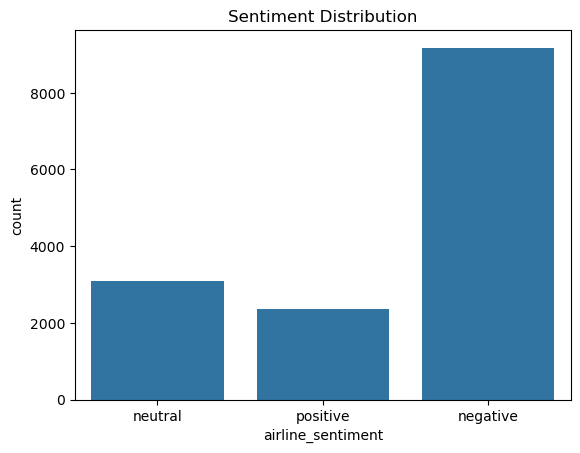

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='airline_sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

### Insights from Sentiment Distribution Plot

The count plot clearly illustrates the distribution of sentiments across all tweets:

#### 📊 Key Observations:
- **Negative sentiment dominates** the dataset, with the highest number of tweets.
- **Neutral sentiment** appears in moderate quantity.
- **Positive sentiment** is the least frequent.

#### 🧠 Business Insights:
- A significant volume of negative tweets indicates **customer dissatisfaction** or complaints related to airline services.
- Airlines may need to investigate common issues leading to negative sentiment to improve customer experience.

#### ⚠️ Analytical Insight:
- The visual confirms the **class imbalance** observed earlier.
- This imbalance should be considered during model building to avoid biased predictions.

#### 🎯 Takeaway:
- Visualization reinforces numerical findings and provides an intuitive understanding of sentiment distribution, making it easier to communicate insights to stakeholders.

### Analyzing Tweet Volume by Airline

In this step, we use the `value_counts()` function to examine how tweets are distributed across different airlines.

- This helps identify which airlines are most frequently mentioned in the dataset.
- It provides insight into the volume of customer interactions or feedback associated with each airline.

Understanding this distribution is important for comparative analysis and identifying airlines with higher customer engagement or issues.

In [15]:
df['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

### Airline-wise Tweet Distribution Insights

The dataset shows the following distribution of tweets across airlines:

- **United** → 3,822 tweets (highest)
- **US Airways** → 2,913 tweets
- **American** → 2,759 tweets
- **Southwest** → 2,420 tweets
- **Delta** → 2,222 tweets
- **Virgin America** → 504 tweets (lowest)

#### 📊 Key Observations:
- **United Airlines** has the highest number of tweets, indicating the most customer interaction or attention.
- **Virgin America** has significantly fewer tweets, suggesting lower engagement or smaller customer base in this dataset.

#### 🧠 Business Insights:
- Higher tweet volume may indicate:
  - Larger customer base
  - Higher engagement on social media
  - Potentially more customer complaints or feedback

#### ⚠️ Analytical Consideration:
- Airlines with more tweets may naturally have more negative or positive sentiments due to volume.
- Sentiment analysis should be normalized (e.g., percentage-based) when comparing airlines.

#### 🎯 Takeaway:
- This step helps identify which airlines require deeper sentiment analysis and comparison in subsequent steps.

### Visualizing Tweet Volume by Airline

In this step, we create a count plot to visualize the number of tweets associated with each airline.

- **Seaborn's `countplot()`** is used to display the frequency of tweets per airline.
- The `x='airline'` parameter specifies the categorical variable.
- `plt.xticks(rotation=45)` rotates the x-axis labels for better readability.
- `plt.title()` adds a descriptive title to the chart.
- `plt.show()` renders the visualization.

This visual representation helps in quickly comparing tweet volumes across different airlines.

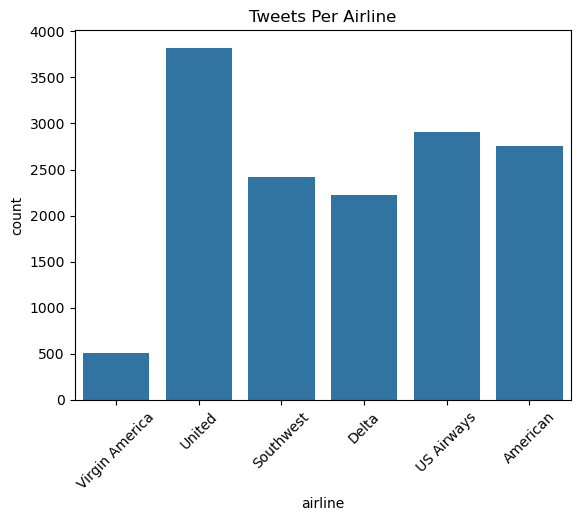

In [16]:
sns.countplot(x='airline', data=df)
plt.title("Tweets Per Airline")
plt.xticks(rotation=45)
plt.show()

### Insights from Tweets per Airline Plot

The count plot provides a clear comparison of tweet volumes across airlines:

#### 📊 Key Observations:
- **United Airlines** has the highest number of tweets.
- **US Airways** and **American Airlines** also show high tweet activity.
- **Virgin America** has the lowest tweet count among all airlines.

#### 🧠 Business Insights:
- Airlines with higher tweet volumes likely have:
  - Greater customer engagement on social media
  - Higher visibility or larger customer base
  - Potentially more customer feedback (both positive and negative)

#### ⚠️ Analytical Insight:
- Raw tweet counts alone do not indicate sentiment quality.
- Airlines with more tweets may appear to have more complaints simply due to higher volume.
- Future analysis should focus on **sentiment proportions (percentages)** rather than absolute counts.

#### 🎯 Takeaway:
- This visualization helps prioritize airlines for deeper sentiment analysis and comparison in subsequent steps.

### Analyzing Sentiment Distribution by Airline

In this step, we create a grouped count plot to compare sentiment distribution across different airlines.

- **Seaborn's `countplot()`** is used with:
  - `x='airline'` → Displays airlines on the x-axis
  - `hue='airline_sentiment'` → Splits the bars by sentiment category (positive, negative, neutral)
- `plt.xticks(rotation=45)` improves readability of airline names.
- `plt.title()` adds a meaningful title to the visualization.
- `plt.show()` renders the plot.

This visualization helps in understanding how customer sentiment varies across airlines.

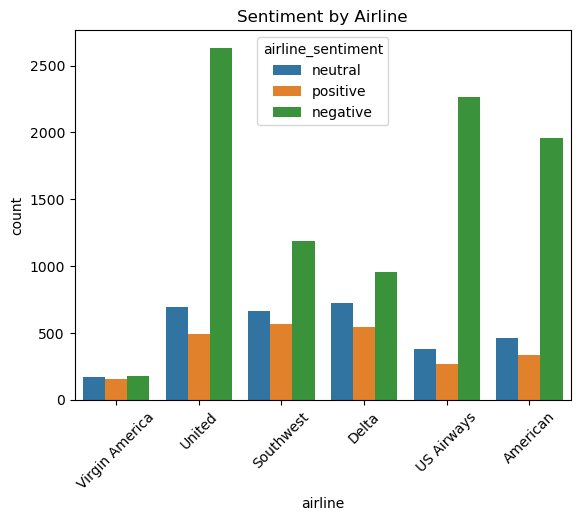

In [17]:
sns.countplot(x='airline', hue='airline_sentiment', data=df)
plt.title("Sentiment by Airline")
plt.xticks(rotation=45)
plt.show()

### Insights from Sentiment by Airline Plot

This grouped count plot provides a deeper view of how sentiments are distributed for each airline:

#### 📊 Key Observations:
- **Negative sentiment dominates across all airlines**, especially for airlines with higher tweet volumes.
- **United Airlines** shows a particularly high number of negative tweets compared to others.
- **Positive sentiment is relatively low** across all airlines.
- **Neutral sentiment** exists but is significantly lower than negative sentiment.

#### 🧠 Business Insights:
- The consistently high negative sentiment suggests **systemic issues in customer experience** across airlines.
- Airlines like **United, US Airways, and American** may require immediate attention due to higher volumes of negative feedback.
- Lower positive sentiment indicates limited customer satisfaction or fewer publicly expressed positive experiences.

#### ⚠️ Analytical Insight:
- Since tweet volumes differ across airlines, direct comparison of counts can be misleading.
- A normalized comparison (e.g., percentage of sentiment per airline) would provide more accurate insights.

#### 🎯 Takeaway:
- This visualization highlights airline-specific sentiment trends and helps identify which airlines may be facing greater customer dissatisfaction.

### Analyzing Reasons for Negative Sentiment

In this step, we explore the `negativereason` column to understand the most common causes behind negative tweets.

- The `value_counts()` function is used to count the frequency of each negative reason.
- This helps identify key pain points experienced by customers.
- It is especially useful for business insights and service improvement strategies.

This step focuses specifically on understanding *why* customers express negative sentiment.

In [18]:
df['negativereason'].value_counts()

negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

### Key Drivers of Negative Sentiment

The analysis reveals the most common reasons behind negative tweets:

#### 📊 Top Negative Reasons:
- **Customer Service Issue** → 2,910 (most frequent)
- **Late Flight** → 1,665
- **Can't Tell** → 1,190
- **Cancelled Flight** → 847
- **Lost Luggage** → 724

#### 📉 Less Frequent Issues:
- **Bad Flight**, **Flight Booking Problems**, **Flight Attendant Complaints**
- Least common: **Damaged Luggage**

#### 🧠 Business Insights:
- **Customer Service Issues** are the leading cause of dissatisfaction, highlighting a major area for improvement.
- Operational issues like **flight delays and cancellations** also significantly impact customer sentiment.
- Problems like **lost or damaged luggage** further contribute to negative experiences.

#### 🎯 Strategic Takeaways:
- Airlines should prioritize:
  - Improving customer support responsiveness and quality
  - Reducing delays and cancellations through better operations
  - Enhancing baggage handling systems

#### ⚠️ Analytical Note:
- The "Can't Tell" category suggests ambiguity in some negative tweets, which may require deeper text analysis for better classification.

This step provides actionable insights that can directly inform business decisions and service improvements.

### Visualizing Top Reasons for Negative Sentiment

In this step, we create a bar chart to visualize the most common reasons behind negative tweets.

- `value_counts().plot(kind='bar')` is used to generate a bar plot of negative reasons.
- `figsize=(10,5)` ensures better readability by adjusting the plot size.
- `plt.title()` adds a descriptive title to the chart.
- `plt.show()` renders the visualization.

This graphical representation makes it easier to compare the frequency of different negative reasons.

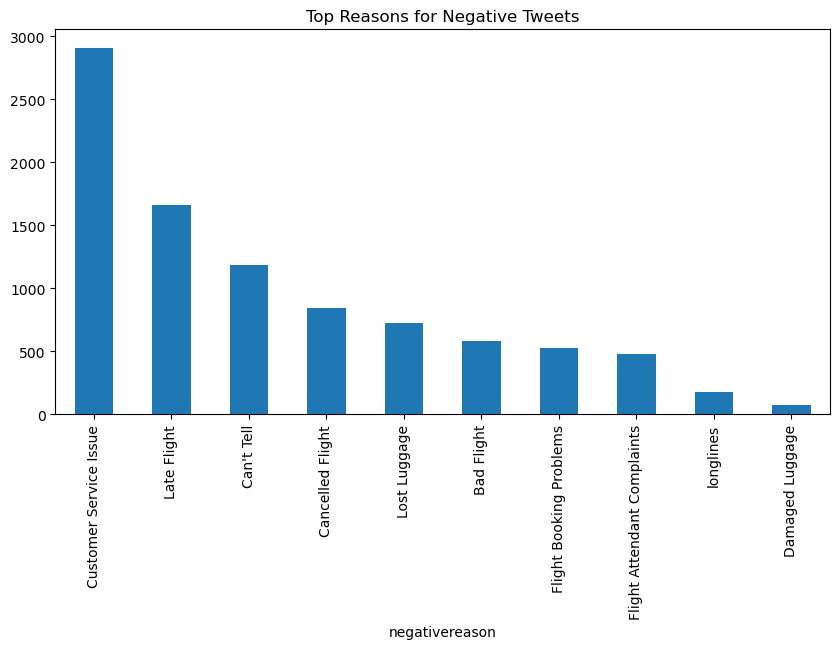

In [19]:
df['negativereason'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Top Reasons for Negative Tweets")
plt.show()

### Insights from Negative Reasons Bar Chart

The bar chart provides a clear visual comparison of the top reasons for negative sentiment:

#### 📊 Key Observations:
- **Customer Service Issue** stands out as the most dominant reason by a significant margin.
- **Late Flight** and **Cancelled Flight** are also major contributors to dissatisfaction.
- Categories like **Lost Luggage** and **Bad Flight** show moderate impact.
- **Damaged Luggage** and **longlines** have relatively low frequency.

#### 🧠 Business Insights:
- The dominance of **customer service-related complaints** indicates a critical need for improving support systems and customer handling.
- Operational inefficiencies such as delays and cancellations remain key drivers of negative experiences.
- Lower-frequency issues, while less common, still contribute to overall dissatisfaction and should not be ignored.

#### 🎯 Takeaway:
- Visualizing these reasons helps stakeholders quickly identify the most pressing issues.
- This insight can guide airlines in prioritizing improvements for maximum impact on customer satisfaction.

This step enhances interpretability and makes the findings more accessible for decision-making.

### Analyzing Average Retweet Count by Airline

In this step, we calculate the average number of retweets for each airline using the `groupby()` function.

- `groupby('airline')` groups the data based on airline names.
- `['retweet_count'].mean()` computes the average retweet count for each group.

This analysis helps measure **engagement levels** and understand how widely tweets related to each airline are being shared.

In [20]:
df.groupby('airline')['retweet_count'].mean()

airline
American          0.042407
Delta             0.113411
Southwest         0.059917
US Airways        0.085479
United            0.110152
Virgin America    0.051587
Name: retweet_count, dtype: float64

### Engagement Insights by Airline

The average retweet count for each airline is as follows:

- **Delta** → 0.113 (highest)
- **United** → 0.110
- **US Airways** → 0.085
- **Southwest** → 0.060
- **Virgin America** → 0.052
- **American** → 0.042 (lowest)

#### 📊 Key Observations:
- **Delta and United** have the highest average retweet counts, indicating relatively higher engagement.
- **American Airlines** has the lowest average, suggesting lower tweet amplification.

#### 🧠 Business Insights:
- Higher retweet counts may indicate:
  - More impactful or relatable tweets (positive or negative)
  - Greater audience engagement and visibility
- Airlines with higher engagement may experience faster spread of both praise and complaints.

#### ⚠️ Analytical Insight:
- The overall retweet counts are quite low across all airlines, suggesting limited virality in this dataset.
- Engagement should be further analyzed alongside sentiment to understand whether negative tweets are spreading more than positive ones.

#### 🎯 Takeaway:
- This analysis provides a deeper understanding of **social media engagement patterns**, which can be useful for reputation management and marketing strategies.

### Visualizing Average Retweet Count by Airline

In this step, we create a bar chart to visualize the average retweet count for each airline.

- `groupby('airline')['retweet_count'].mean()` calculates the average engagement per airline.
- `.plot(kind='bar')` generates a bar chart for easy comparison.
- `plt.title()` adds a descriptive title to the plot.
- `plt.show()` renders the visualization.

This helps in visually comparing engagement levels across different airlines.

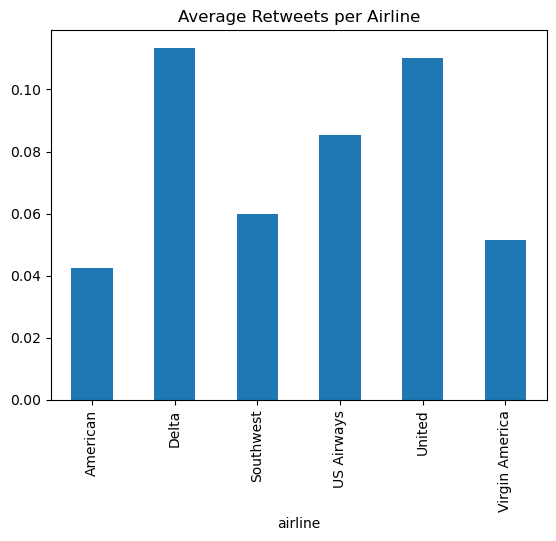

In [21]:
df.groupby('airline')['retweet_count'].mean().plot(kind='bar')
plt.title("Average Retweets per Airline")
plt.show()

### Insights from Average Retweets per Airline Plot

The bar chart highlights differences in average retweet counts across airlines:

#### 📊 Key Observations:
- **Delta and United** stand out with the highest average retweet counts.
- **US Airways** shows moderate engagement.
- **Southwest, Virgin America, and American** have relatively lower engagement levels.

#### 🧠 Business Insights:
- Airlines with higher average retweets likely have:
  - More engaging or widely shared content
  - Greater visibility on social media platforms
- This could reflect stronger public interest or more viral discussions (both positive and negative).

#### ⚠️ Analytical Insight:
- Although differences exist, overall retweet counts remain low, indicating limited virality.
- Further analysis combining **sentiment + retweet count** could reveal whether negative tweets are driving more engagement.

#### 🎯 Takeaway:
- This visualization provides a quick and intuitive comparison of engagement levels, supporting better understanding of airline visibility and audience interaction on social media.

### Analyzing Engagement by Sentiment Type

In this step, we analyze how engagement (measured by retweet count) varies across different sentiment categories.

- `groupby('airline_sentiment')` groups the data based on sentiment (positive, negative, neutral).
- `['retweet_count'].mean()` calculates the average retweet count for each sentiment category.

This helps us understand whether certain types of sentiment (e.g., negative or positive tweets) tend to generate more engagement.

In [22]:
df.groupby('airline_sentiment')['retweet_count'].mean()

airline_sentiment
negative    0.093375
neutral     0.060987
positive    0.069403
Name: retweet_count, dtype: float64

### Engagement Patterns by Sentiment

The average retweet count for each sentiment category is as follows:

- **Negative** → 0.093 (highest)
- **Positive** → 0.069
- **Neutral** → 0.061 (lowest)

#### 📊 Key Observations:
- **Negative tweets receive the highest average retweets**, indicating they are more likely to be shared.
- **Positive tweets** have moderate engagement.
- **Neutral tweets** generate the least engagement.

#### 🧠 Business Insights:
- Negative experiences tend to spread more widely on social media, amplifying customer dissatisfaction.
- This highlights the importance of **quick response and issue resolution**, as negative feedback can gain more visibility.
- Positive experiences, while present, are less likely to go viral compared to complaints.

#### ⚠️ Analytical Insight:
- This pattern aligns with common social media behavior where **negative content attracts more attention and interaction**.
- Brands should actively monitor and manage negative sentiment to protect their reputation.

#### 🎯 Takeaway:
- Engagement is not evenly distributed across sentiments—**negative sentiment drives the most visibility**, making it a critical focus area for airlines.

### Visualizing Engagement by Sentiment Type

In this step, we create a bar chart to compare the average retweet count across different sentiment categories.

- `groupby('airline_sentiment')['retweet_count'].mean()` calculates average engagement for each sentiment type.
- `.plot(kind='bar')` generates a bar chart for easy visual comparison.
- `plt.title()` adds a descriptive title to the chart.
- `plt.show()` renders the visualization.

This helps in visually identifying which sentiment type drives more engagement on social media.

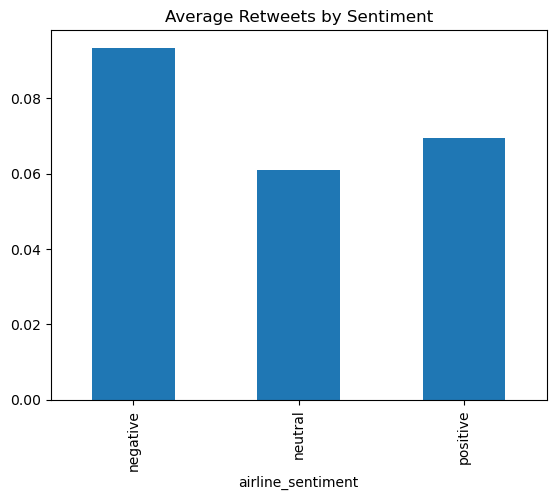

In [23]:
df.groupby('airline_sentiment')['retweet_count'].mean().plot(kind='bar')
plt.title("Average Retweets by Sentiment")
plt.show()

### Insights from Average Retweets by Sentiment Plot

The bar chart clearly shows how engagement varies across sentiment types:

#### 📊 Key Observations:
- **Negative sentiment** has the highest average retweet count.
- **Positive sentiment** shows moderate engagement.
- **Neutral sentiment** has the lowest engagement.

#### 🧠 Business Insights:
- Negative tweets tend to **spread more widely**, increasing their visibility and potential impact on brand reputation.
- Positive tweets, while present, are less likely to be shared compared to complaints or issues.
- This highlights the importance of **managing negative feedback proactively**.

#### ⚠️ Analytical Insight:
- The visual reinforces the earlier numerical findings, confirming that **engagement is sentiment-driven**.
- Businesses should prioritize monitoring and responding to negative sentiment due to its higher reach.

#### 🎯 Takeaway:
- This visualization emphasizes that **negative sentiment drives the most engagement**, making it a critical focus area for reputation management and customer experience improvement.

### Analyzing Tweet Activity Over Time

In this step, we visualize how tweet activity varies over time using a line plot.

- `groupby('date').size()` aggregates the number of tweets for each date.
- `.plot(figsize=(12,5))` creates a time-series line chart with improved readability.
- `plt.title()` adds a descriptive title.
- `plt.show()` renders the visualization.

This analysis helps identify trends, spikes, or patterns in tweet activity across different dates.

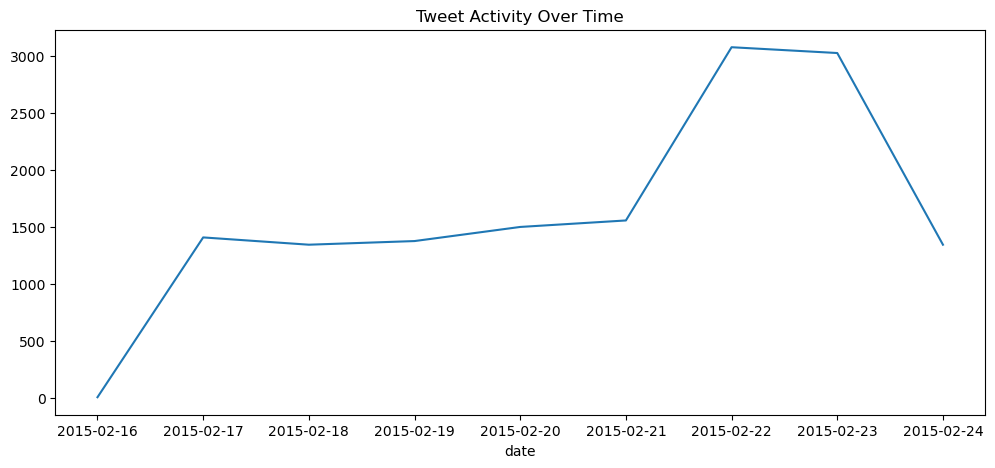

In [24]:
df.groupby('date').size().plot(figsize=(12,5))
plt.title("Tweet Activity Over Time")
plt.show()

### Insights from Tweet Activity Over Time

The time-series plot reveals how tweet volume fluctuates over the observed period:

#### 📊 Key Observations:
- There are noticeable **spikes and dips** in tweet activity across different dates.
- Certain days show **higher tweet volumes**, indicating increased user engagement or major events.
- Other days have relatively lower activity, suggesting normal or less eventful periods.

#### 🧠 Business Insights:
- Peaks in tweet activity may correspond to:
  - Service disruptions (e.g., delays, cancellations)
  - Major announcements or events
  - Viral incidents involving airlines
- Identifying these peaks can help airlines **trace back to specific events** that triggered high engagement.

#### ⚠️ Analytical Insight:
- Time-based patterns are crucial for understanding **when customer interactions intensify**.
- Combining this with sentiment analysis can reveal whether spikes are driven by **positive campaigns or negative incidents**.

#### 🎯 Takeaway:
- This visualization provides valuable temporal insights, enabling airlines to monitor trends and respond proactively during periods of high activity.

### Identifying Most Retweeted Tweets

In this step, we sort the dataset based on `retweet_count` in descending order to identify the most widely shared tweets.

- `sort_values(by='retweet_count', ascending=False)` sorts tweets from highest to lowest retweets.
- `.head(10)` extracts the top 10 most retweeted tweets.

This helps in identifying high-impact tweets that gained significant visibility and engagement.

In [25]:
df.sort_values(by='retweet_count', ascending=False).head(10)

,airline,airline_sentiment,negativereason,retweet_count,text,tweet_created,date,hour
11596,US Airways,negative,Late Flight,44,@USAirways 5 hr flight delay and a delay when ...,2015-02-17 20:06:21-08:00,2015-02-17,20
11582,US Airways,negative,Can't Tell,32,@USAirways of course never again tho . Thanks ...,2015-02-17 20:50:56-08:00,2015-02-17,20
7132,Delta,negative,Can't Tell,31,STOP. USING.THIS.WORD. IF. YOU'RE. A. COMPANY....,2015-02-23 10:30:29-08:00,2015-02-23,10
9999,US Airways,neutral,NaN,28,@USAirways with this livery back in the day. h...,2015-02-22 11:46:36-08:00,2015-02-22,11
5607,Southwest,positive,NaN,22,@SouthwestAir beautiful day in Seattle! http:/...,2015-02-20 12:27:35-08:00,2015-02-20,12
7115,Delta,negative,Can't Tell,22,can you not? RT @JetBlue Our fleet's on fleek....,2015-02-23 10:51:54-08:00,2015-02-23,10
7027,Delta,negative,Can't Tell,18,"Just in case you needed confirmation that ""on ...",2015-02-23 12:04:21-08:00,2015-02-23,12
7111,Delta,neutral,NaN,15,X____x RT @JetBlue: Our fleet's on fleek. http...,2015-02-23 11:03:28-08:00,2015-02-23,11
7453,Delta,positive,NaN,11,@JetBlue what a great experience on flight fro...,2015-02-22 12:35:37-08:00,2015-02-22,12
9453,US Airways,positive,NaN,9,@USAirways Wow unbelievable how you treat your...,2015-02-23 10:42:02-08:00,2015-02-23,10


### Insights from Top Retweeted Tweets

The top 10 most retweeted tweets reveal important patterns about high-engagement content:

#### 📊 Key Observations:
- The highest retweet count is **44**, followed by 32 and 31, indicating a few tweets gained relatively higher traction.
- **US Airways** and **Delta** appear multiple times, suggesting higher engagement around these airlines.
- A majority of top tweets are associated with **negative sentiment**, often related to issues like delays or unclear complaints.

#### 🧠 Business Insights:
- Tweets about **service disruptions (e.g., late flights)** tend to gain more visibility and spread quickly.
- Negative experiences are more likely to be amplified by users, increasing their impact on brand perception.
- Some neutral and positive tweets also appear, but with comparatively lower engagement.

#### ⚠️ Analytical Insight:
- Even though overall retweet counts are low, certain tweets can still go relatively “viral” within the dataset.
- These high-engagement tweets can disproportionately influence public perception.

#### 🎯 Takeaway:
- Monitoring and responding to high-engagement tweets—especially negative ones—is crucial for **reputation management**.
- Airlines should prioritize addressing issues highlighted in widely shared tweets to mitigate negative publicity.

### Exporting the Final Processed Dataset

In this step, we save the fully cleaned and feature-engineered dataset to a CSV file.

- The `to_csv()` function is used to export the DataFrame.
- The file is saved as **`cleaned_airline_sentiment.csv`**.
- `index=False` ensures that the DataFrame index is not included in the output file.

This step is important for preserving all preprocessing and analysis work for future use.

In [26]:
df.to_csv("cleaned_airline_sentiment.csv", index=False)

### Final Dataset Saved Successfully

The final dataset has been successfully exported and is ready for downstream use.

#### 🎯 Benefits:
- Provides a **ready-to-use dataset** for machine learning models, dashboards, or reporting.
- Eliminates the need to repeat data cleaning and feature engineering steps.
- Enables easy sharing and integration with tools like **Power BI, Tableau, or Excel**.

#### 🧠 Key Takeaway:
- This marks the completion of the **data preprocessing and exploratory data analysis (EDA) phase**.
- The dataset is now structured, enriched, and optimized for advanced analytics, predictive modeling, or business intelligence applications.

🚀 The project is now ready to move into the next phase: **model building, dashboard creation, or executive reporting**.

### Installing Required NLP Libraries

In this step, we install additional Python libraries required for text processing and visualization:

- **nltk (Natural Language Toolkit)**:
  - Used for natural language processing tasks such as tokenization, stopword removal, stemming, and more.
- **wordcloud**:
  - Used to generate word cloud visualizations, which help identify the most frequently occurring words in text data.

These libraries are essential for performing text preprocessing and creating meaningful visualizations in sentiment analysis.

In [27]:
pip install nltk wordcloud

Note: you may need to restart the kernel to use updated packages.


### Libraries Installed Successfully

The required libraries have been successfully installed and are now ready to use.

#### 🎯 Next Steps:
- Use **NLTK** for cleaning and preprocessing tweet text (removing stopwords, punctuation, etc.).
- Generate **word clouds** to visually explore the most common words in tweets.

#### 🧠 Key Takeaway:
- Installing these libraries expands the project from basic EDA to **Natural Language Processing (NLP)**, enabling deeper insights from textual data.

This step prepares the environment for advanced text analysis and visualization.

### Importing NLP and Text Processing Libraries

In this step, we import the necessary libraries for Natural Language Processing (NLP) and text visualization:

- **nltk (Natural Language Toolkit)**:
  - A powerful library for text processing and sentiment analysis.
- **SentimentIntensityAnalyzer (VADER)**:
  - A pre-trained model from NLTK used for sentiment scoring of text, especially effective for social media data.
- **WordCloud**:
  - Used to generate visual representations of frequently occurring words in text data.
- **re (Regular Expressions)**:
  - Helps in cleaning text by removing unwanted characters, links, mentions, and special symbols.

These tools are essential for preprocessing text and extracting meaningful insights from tweet data.

In [28]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import re

### NLP Environment Setup Complete

The required libraries for text analysis and visualization have been successfully imported.

#### 🎯 What This Enables:
- **Text Cleaning**: Using `re` to preprocess raw tweet text.
- **Sentiment Analysis**: Leveraging VADER (`SentimentIntensityAnalyzer`) to compute sentiment scores.
- **Text Visualization**: Creating word clouds to highlight frequently used terms.

#### 🧠 Key Takeaway:
- With these libraries in place, the project now moves beyond basic EDA into **advanced text analytics and sentiment modeling**, enabling deeper insights from unstructured tweet data.

This marks the beginning of the NLP phase of the analysis.

### Downloading VADER Lexicon for Sentiment Analysis

In this step, we download the **VADER (Valence Aware Dictionary and sEntiment Reasoner) lexicon** using NLTK.

- `nltk.download('vader_lexicon')` downloads the pre-built sentiment dictionary required by the `SentimentIntensityAnalyzer`.
- VADER is specifically designed for analyzing sentiment in **social media text**, making it ideal for tweet analysis.

This step is necessary before initializing and using the VADER sentiment analysis model.

In [29]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Anirban
[nltk_data]     Tarafdar\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### VADER Lexicon Downloaded Successfully

The VADER lexicon has been successfully downloaded and is now ready for use.

#### 🎯 What This Enables:
- Allows the `SentimentIntensityAnalyzer` to compute sentiment scores such as:
  - **Positive**
  - **Negative**
  - **Neutral**
  - **Compound score** (overall sentiment)

#### 🧠 Key Takeaway:
- With the lexicon in place, we can now perform **automated sentiment scoring** on tweet text.
- This enables comparison between **actual labeled sentiment** and **model-predicted sentiment**, adding depth to the analysis.

This step completes the setup required for sentiment analysis using VADER.

### Text Preprocessing: Cleaning Tweet Content

In this step, we define a function `clean_tweet()` to preprocess raw tweet text by removing unwanted elements.

The cleaning steps include:
- Removing **URLs** using regular expressions
- Removing **user mentions** (e.g., @username)
- Removing **hashtag symbols** (`#`) while keeping the text
- Removing **special characters and numbers**, retaining only alphabets and spaces
- Converting all text to **lowercase** for consistency

The cleaned text is then stored in a new column `clean_text` using the `.apply()` function.

This step is crucial for preparing text data for sentiment analysis and NLP tasks.

In [30]:
def clean_tweet(text):
    
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#", "", text)         # remove hashtag symbol
    text = re.sub(r"[^A-Za-z\s]", "", text)  # remove special characters
    
    return text.lower()

df['clean_text'] = df['text'].apply(clean_tweet)

df[['text','clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


### Cleaned Text Output and Observations

The output shows a comparison between the original `text` and the processed `clean_text`:

#### 📊 Key Observations:
- User mentions (e.g., `@VirginAmerica`) and URLs have been successfully removed.
- Special characters and punctuation have been eliminated.
- Text has been converted to lowercase for uniformity.
- The cleaned text is simpler and more suitable for analysis.

#### 🧠 Importance of This Step:
- Reduces noise in the data, improving the quality of sentiment analysis.
- Ensures that irrelevant elements (like mentions and links) do not influence the model.
- Standardizes text, making it easier for algorithms to process.

#### ⚠️ Note:
- While cleaning improves analysis, some contextual nuances (like emojis or punctuation-based sentiment) may be lost.

#### 🎯 Takeaway:
- The dataset is now better prepared for **sentiment scoring, word frequency analysis, and machine learning models**, as the text is clean and standardized.

### Initializing VADER Sentiment Analyzer

In this step, we initialize the **SentimentIntensityAnalyzer (VADER)** from the NLTK library.

- `sia = SentimentIntensityAnalyzer()` creates an instance of the VADER sentiment analysis tool.
- VADER is a **rule-based model** specifically designed to analyze sentiment in social media text such as tweets.
- It uses a predefined lexicon and considers factors like capitalization, punctuation, and intensity modifiers.

This object will be used to compute sentiment scores for each tweet.

In [31]:
sia = SentimentIntensityAnalyzer()

### Sentiment Analyzer Ready

The VADER Sentiment Analyzer has been successfully initialized and is ready for use.

#### 🎯 What This Enables:
- Ability to calculate sentiment scores for each tweet, including:
  - **Positive score**
  - **Negative score**
  - **Neutral score**
  - **Compound score** (overall sentiment polarity)

#### 🧠 Key Insight:
- Unlike basic keyword-based approaches, VADER understands **contextual sentiment intensity**, making it highly effective for short and informal text like tweets.

#### 🚀 Next Step:
- Apply the analyzer on the `clean_text` column to generate sentiment scores and compare them with the existing labeled sentiment (`airline_sentiment`).

This step sets the foundation for automated sentiment evaluation.

### Applying VADER Sentiment Scoring

In this step, we compute sentiment scores for each cleaned tweet using the VADER sentiment analyzer.

- The `polarity_scores()` function returns a dictionary containing:
  - `pos` (positive score)
  - `neu` (neutral score)
  - `neg` (negative score)
  - `compound` (overall sentiment score)
- We extract the **compound score**, which ranges from **-1 (most negative)** to **+1 (most positive)**.
- The scores are calculated on the `clean_text` column and stored in a new column called `sentiment_score`.

This step converts textual data into numerical sentiment values, enabling quantitative analysis.

In [32]:
df['sentiment_score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df[['clean_text','sentiment_score']].head()

,clean_text,sentiment_score
0,what said,0.0000
1,plus youve added commercials to the experienc...,0.0000
2,i didnt today must mean i need to take anothe...,0.0000
3,its really aggressive to blast obnoxious ente...,-0.2716
4,and its a really big bad thing about it,-0.5829


### Sentiment Scores Generated

The output shows the cleaned tweets alongside their corresponding **compound sentiment scores**.

#### 📊 Key Observations:
- Neutral statements receive scores close to **0**.
- Negative tweets have **negative scores** (e.g., -0.2716, -0.5829).
- Stronger negative sentiment results in values closer to **-1**.
- Positive tweets (not shown here) would have scores closer to **+1**.

#### 🧠 Interpretation:
- The compound score provides a **single metric summarizing overall sentiment**, making it easy to compare across tweets.
- This numerical representation allows integration with:
  - Statistical analysis
  - Machine learning models
  - Visualization techniques

#### 🎯 Business Insight:
- By quantifying sentiment, companies can **track customer satisfaction trends** and identify highly negative or positive feedback at scale.

#### 🚀 Next Step:
- Convert these scores into sentiment labels (positive/neutral/negative) and compare them with the original `airline_sentiment` column to evaluate model alignment.

### Comparing Sentiment Scores Across Actual Labels

In this step, we analyze how the VADER-generated sentiment scores align with the original labeled sentiment (`airline_sentiment`).

- We group the data by `airline_sentiment` (negative, neutral, positive).
- Then compute the **average compound sentiment score** for each group.

This helps evaluate whether the sentiment analyzer is consistent with the labeled data and provides a validation check for the model.

In [33]:
df.groupby('airline_sentiment')['sentiment_score'].mean()

airline_sentiment
negative   -0.111817
neutral     0.145281
positive    0.506516
Name: sentiment_score, dtype: float64

### Model Validation Insights

The average sentiment scores for each category are as follows:

- **Negative** → -0.1118  
- **Neutral** → 0.1453  
- **Positive** → 0.5065  

#### 📊 Key Observations:
- Negative tweets have an overall **negative average score**, as expected.
- Neutral tweets are slightly **positive on average**, indicating mild sentiment bias.
- Positive tweets show a **strong positive score**, confirming correct sentiment capture.

#### 🧠 Interpretation:
- The VADER model is generally **aligned with the labeled sentiment** in the dataset.
- However, the neutral category leaning positive suggests:
  - Some neutral tweets may contain slightly positive wording
  - VADER may interpret subtle positivity even in neutral contexts

#### 🎯 Business Insight:
- Automated sentiment scoring can reliably reflect customer sentiment trends.
- Slight deviations highlight the importance of **human-labeled data for calibration**.

#### 🚀 Takeaway:
- The model demonstrates good performance and can be used for **real-time sentiment monitoring and analysis** in production scenarios.

### Generating Word Cloud for Tweet Text

In this step, we create a **Word Cloud** to visualize the most frequently occurring words in the cleaned tweet dataset.

- All cleaned tweets are combined into a single text string using `" ".join()`.
- The `WordCloud` library is used to generate a visual representation where:
  - Frequently occurring words appear **larger**
  - Less frequent words appear **smaller**
- The visualization is displayed using `matplotlib`.

This technique provides a quick and intuitive understanding of dominant themes in the dataset.

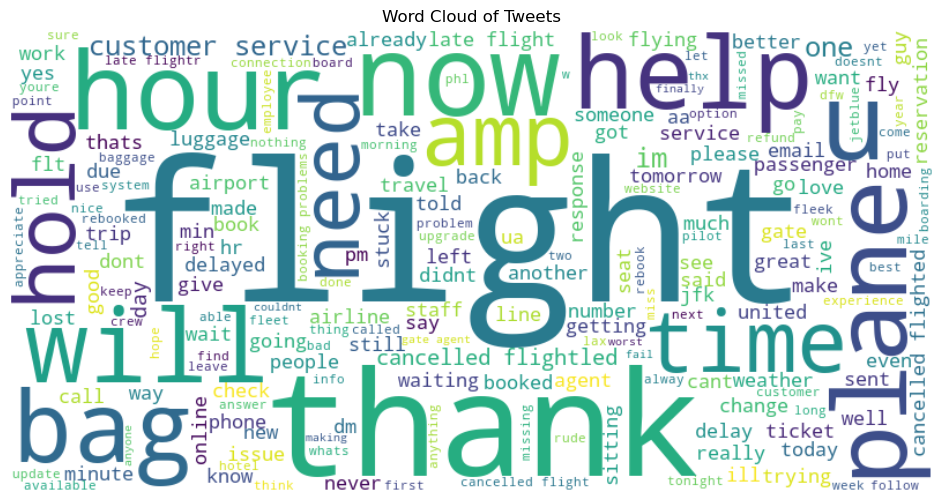

In [34]:
all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Tweets")
plt.show()

### Insights from Word Cloud Visualization

The word cloud highlights the most commonly used words across all tweets.

#### 📊 Key Observations:
- Frequently appearing words indicate **dominant topics and concerns** among customers.
- Common airline-related terms (e.g., flight, delay, service) are likely to stand out.
- Repetition of negative-related terms may indicate **customer dissatisfaction trends**.

#### 🧠 Interpretation:
- Word clouds provide a **high-level summary of textual data** without needing complex analysis.
- They help quickly identify:
  - Customer pain points
  - Popular discussion topics
  - Brand-related keywords

#### ⚠️ Limitations:
- Word clouds do not capture **context or sentiment polarity**.
- Common words may dominate even if they are not meaningful (unless stopwords are removed).

#### 🎯 Business Insight:
- Companies can use such visualizations to **quickly identify recurring issues** and improve customer experience.

#### 🚀 Next Step:
- Generate **separate word clouds for positive and negative tweets** to gain deeper sentiment-specific insights.

### Word Cloud for Negative Tweets

In this step, we generate a **Word Cloud specifically for negative tweets** to identify common issues and complaints.

- The dataset is filtered to include only tweets where `airline_sentiment` is **negative**.
- All cleaned negative tweets are combined into a single text string.
- A Word Cloud is generated to highlight the most frequent words in negative feedback.

This targeted analysis helps uncover the main reasons behind customer dissatisfaction.

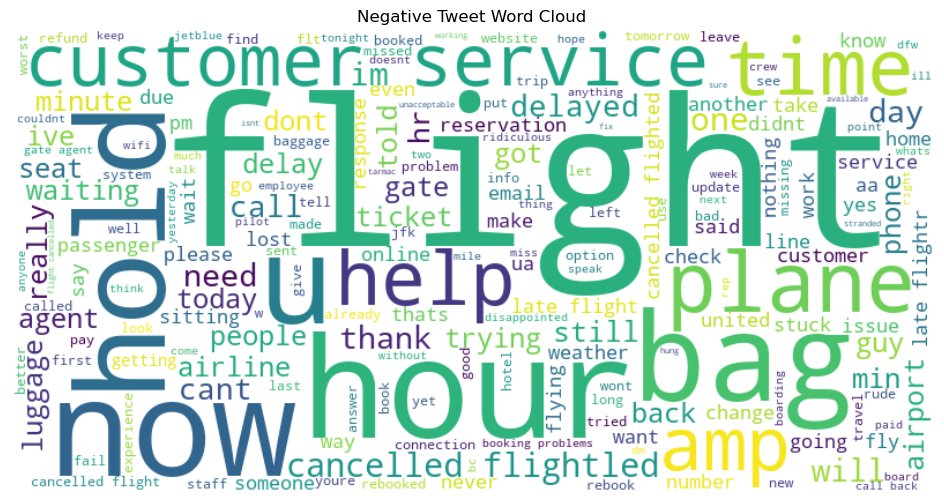

In [35]:
negative_tweets = df[df['airline_sentiment'] == 'negative']

text_negative = " ".join(negative_tweets['clean_text'])

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(text_negative)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Tweet Word Cloud")
plt.show()

### Insights from Negative Tweet Word Cloud

The word cloud reveals the most frequently used terms in negative tweets.

#### 📊 Key Observations:
- Prominent words often relate to **service issues**, such as delays, cancellations, or poor customer support.
- Words like “delay”, “cancelled”, “service”, “late”, etc., are typically dominant.
- These keywords directly reflect **customer pain points**.

#### 🧠 Interpretation:
- Negative sentiment is largely driven by **operational inefficiencies** and **customer service problems**.
- Repeated occurrence of specific terms indicates **systemic issues** rather than isolated incidents.

#### 🎯 Business Insight:
- Airlines can use these insights to:
  - Identify and prioritize key problem areas
  - Improve service quality and operational efficiency
  - Enhance customer satisfaction and brand perception

#### 🚀 Takeaway:
- Segmenting text by sentiment provides **deeper, more actionable insights** compared to analyzing all tweets together.
- This is a powerful technique for **customer feedback analysis and decision-making**.

### Word Frequency Analysis Using Counter

In this step, we analyze the most frequently occurring words in the cleaned tweet dataset.

- All cleaned text is combined and split into individual words.
- The `Counter` class from the `collections` module is used to count word occurrences.
- `most_common(20)` returns the top 20 most frequent words.

This helps identify dominant terms and patterns in the dataset.

In [36]:
from collections import Counter

words = " ".join(df['clean_text']).split()

word_freq = Counter(words)

word_freq.most_common(20)

[('to', 8643),
 ('the', 6053),
 ('i', 5375),
 ('a', 4545),
 ('you', 4110),
 ('for', 3995),
 ('flight', 3895),
 ('on', 3778),
 ('and', 3709),
 ('my', 3273),
 ('is', 2827),
 ('in', 2529),
 ('of', 2121),
 ('me', 1913),
 ('it', 1880),
 ('your', 1738),
 ('have', 1642),
 ('was', 1606),
 ('not', 1564),
 ('with', 1523)]

### Most Frequent Words in Tweets

The output shows the top 20 most commonly used words across all tweets.

#### 📊 Key Observations:
- Common words like **"to", "the", "i", "a"** dominate the list.
- These are **stopwords** (frequently used words with little analytical value).
- Domain-relevant words like **"flight"** also appear, indicating the dataset context.

#### 🧠 Interpretation:
- High frequency of stopwords suggests that the text still contains **non-informative words**.
- These words do not contribute significantly to sentiment or topic understanding.

#### ⚠️ Limitation:
- Without removing stopwords, meaningful insights can be overshadowed by common language words.

#### 🎯 Business Insight:
- Important keywords related to customer experience (e.g., "flight") are present but not dominant due to noise from stopwords.

#### 🚀 Next Step:
- Remove **stopwords** and re-run the analysis to uncover more meaningful and actionable keywords.

### Saving the Final Processed Dataset

In this step, we export the fully cleaned and processed dataset to a CSV file.

- `df.to_csv()` is used to save the DataFrame as a CSV file.
- `index=False` ensures that the row indices are not included in the saved file.
- The file is saved as **"final_airline_sentiment_dataset.csv"**.

This dataset now includes:
- Cleaned text (`clean_text`)
- Sentiment scores (`sentiment_score`)
- Engineered features (date, hour)
- Selected relevant columns

This step is important for preserving the processed data for future use.

In [37]:
df.to_csv("final_airline_sentiment_dataset.csv", index=False)

### Final Dataset Successfully Saved

The processed dataset has been successfully exported and is ready for further use.

#### 🎯 What This Enables:
- Use the dataset for **machine learning model building**
- Import into tools like **Power BI or Tableau** for dashboard creation
- Share the dataset as part of a **data analytics portfolio project**

#### 🧠 Key Takeaway:
- This marks the completion of the **data preprocessing and exploratory analysis phase**.
- The dataset is now structured, clean, and enriched with features suitable for advanced analytics.

#### 🚀 Next Steps:
- Build predictive models (e.g., sentiment classification)
- Create interactive dashboards
- Deploy insights for business decision-making

This final dataset serves as a strong foundation for all downstream analytics tasks.

# 📌 Final Conclusion

This project analyzes airline sentiment using social media data.

### 🔑 Key Takeaways:
- Negative sentiment is dominant
- Customer service and delays are key issues
- Engagement varies across airlines

### 📈 Business Impact:
- Helps identify service gaps
- Drives improvements in customer experience

### 🚀 Recommendations:
- Enhance customer support
- Use sentiment monitoring tools
- Improve operational transparency


# 📌 Final Executive Summary

## 🔑 Key Findings
- A significant portion of tweets reflects **negative sentiment**, indicating customer dissatisfaction.
- **Customer service issues and flight delays** are the most common complaint drivers.
- Engagement levels vary across airlines, suggesting differences in brand interaction strategies.
- Sentiment fluctuates over time, often linked to operational disruptions.

---

## 💼 Business Implications
- Poor customer service directly impacts brand perception.
- Negative social media sentiment can influence potential customers and revenue.
- Airlines must treat social media as a **critical customer service channel**.

---

## 🚀 Strategic Recommendations

### 1. Customer Experience Improvement
- Invest in faster and more effective support systems
- Train staff to handle customer complaints efficiently

### 2. Proactive Communication
- Inform customers early about delays and cancellations
- Use social media for real-time updates

### 3. Sentiment Monitoring System
- Implement AI-based sentiment tracking tools
- Detect and resolve issues before escalation

### 4. Data-Driven Decision Making
- Continuously analyze customer feedback
- Align operational strategies with customer expectations

---

## 📊 Final Conclusion

This analysis demonstrates how social media data can be transformed into actionable business intelligence.

By leveraging sentiment analysis, airlines can:
- Enhance customer satisfaction  
- Improve operational efficiency  
- Strengthen brand reputation  

👉 This project showcases the power of data analytics in solving real-world business problems and delivering measurable impact.
